<a href="https://colab.research.google.com/github/woojinyeo/Used-Cars-Price-Prediction/blob/main/Capstone_Project_(Full_Code).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Used Cars Price Prediction**

## **Problem Definition**

### **The Context:**

 - As the demand for used cars are getting higher, it is crucial to have reliable data for the prices so that buyers are not overpaying and sellers are nt undervaluing their products
 - Ultiamately, having this data will help both sides make better decisions and be beneficial to market growth, economic, and buisnesses.

### **The objective:**

 - Objective is create a pricing model to predict the price of used cars, which will help sellers and buinesses devise effective strategies
 - In this case, we are helping Cars4U to offer reasonable and competitic prices to buyers and sellers

### **The key questions:**

- How does the given variables affect the price of used cars, and which of them are most significant?
- Which model performs best for this job?
- How accurate is the chosen model in predicting the price for a used car?
- How can Cars4U use the information given by the model to strategize their buisness?

### **The problem formulation**:

- With many variables, the prices of used car prices are curretly uncertain
- Using data science, we will analyze trends and patterns of given data, and create a predictive model to estimate other unknown used car prices
- Ultimately, we are trying to improve the car market and provide useful info for Cars4U for their buisness

### **Data Dictionary**

**S.No.** : Serial Number

**Name** : Name of the car which includes Brand name and Model name

**Location** : The location in which the car is being sold or is available for purchase (Cities)

**Year** : Manufacturing year of the car

**Kilometers_driven** : The total kilometers driven in the car by the previous owner(s) in KM

**Fuel_Type** : The type of fuel used by the car (Petrol, Diesel, Electric, CNG, LPG)

**Transmission** : The type of transmission used by the car (Automatic / Manual)

**Owner** : Type of ownership

**Mileage** : The standard mileage offered by the car company in kmpl or km/kg

**Engine** : The displacement volume of the engine in CC

**Power** : The maximum power of the engine in bhp

**Seats** : The number of seats in the car

**New_Price** : The price of a new car of the same model in INR 100,000

**Price** : The price of the used car in INR 100,000 (**Target Variable**)

### **Loading libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import statsmodels.stats.api as sms
# Import essential libraies for linear model and statistical analysis
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,BaggingRegressor

# Evaluating and tuning the model
from sklearn import metrics
from sklearn.model_selection import GridSearchCV

# Ignoring warnings
import warnings
warnings.filterwarnings('ignore')

### **Let us load the data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Python Course/used_cars.csv')

## Data Overview

- Observations
- Sanity checks

In [ ]:
# First 5 rows of dataset
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,8.61,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,NaN,17.74


In [ ]:
# Last 5 rows of dataset
df.tail()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
7248,7248,Volkswagen Vento Diesel Trendline,Hyderabad,2011,89411,Diesel,Manual,First,20.54,1598.0,103.6,5.0,NaN,NaN
7249,7249,Volkswagen Polo GT TSI,Mumbai,2015,59000,Petrol,Automatic,First,17.21,1197.0,103.6,5.0,NaN,NaN
7250,7250,Nissan Micra Diesel XV,Kolkata,2012,28000,Diesel,Manual,First,23.08,1461.0,63.1,5.0,NaN,NaN
7251,7251,Volkswagen Polo GT TSI,Pune,2013,52262,Petrol,Automatic,Third,17.20,1197.0,103.6,5.0,NaN,NaN
7252,7252,Mercedes-Benz E-Class 2009-2013 E 220 CDI Avan...,Kochi,2014,72443,Diesel,Automatic,First,10.00,2148.0,170.0,5.0,NaN,NaN


- 'Year','Kilometers_Driven', 'Mileage', 'Engine', 'Power',' Seats', 'New Price' and 'Price' seem to be the numberical variables
- 'Name', 'Location', 'Fuel Type', 'Transmission', and 'Owner Type' seem to be categorical varaibles
- S.No is more of an identifyer which isn't really counting towards a varaible

In [ ]:
# Checking datatype of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   float64
 9   Engine             7207 non-null   float64
 10  Power              7078 non-null   float64
 11  Seats              7200 non-null   float64
 12  New_price          1006 non-null   float64
 13  Price              6019 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 793.4+ KB


In [ ]:
# Checking for missing values for each column
df.isnull()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
0,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7248,False,False,False,False,False,False,False,False,False,False,False,False,True,True
7249,False,False,False,False,False,False,False,False,False,False,False,False,True,True
7250,False,False,False,False,False,False,False,False,False,False,False,False,True,True
7251,False,False,False,False,False,False,False,False,False,False,False,False,True,True


In [ ]:
# Checking specifically how many many missing values per column
df.isnull().sum()

,0
S.No.,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,46


The above chart shows the number of missing values per variable in the entire dataset. The 'New_Price' is showing 6247 missing values, which almost all the entires. This is showing that there are barely any new priced cars numbers to work with.

In [ ]:
# Removing S.No column from dataset
df.drop('S.No.', axis=1, inplace=True)

As mentioned before, the 'S.No.' variable is more of an identifyer with no predicitive meaning. So it was removed from the dataset.

## **Exploratory Data Analysis**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions:**

1. What is the summary statistics of the data? Explore summary statistics for numerical variables and the categorical variables
2. Find out number of unique observations in each category of categorical columns? Write your findings/observations/insights
3. Check the extreme values in different columns of the given data and write down the observtions? Remove the data where the values are un-realistic

In [ ]:
# Statistical summary of the numerical variables
df.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,New_price,Price
count,7253.000000,7.253000e+03,7251.000000,7207.000000,7078.000000,7200.000000,1006.000000,6019.000000
mean,2013.365366,5.869906e+04,18.141580,1616.573470,112.765214,5.280417,22.779692,9.479468
std,3.254421,8.442772e+04,4.562197,595.285137,53.493553,0.809277,27.759344,11.187917
min,1996.000000,1.710000e+02,0.000000,72.000000,34.200000,2.000000,3.910000,0.440000
25%,2011.000000,3.400000e+04,15.170000,1198.000000,75.000000,5.000000,7.885000,3.500000
50%,2014.000000,5.341600e+04,18.160000,1493.000000,94.000000,5.000000,11.570000,5.640000
75%,2016.000000,7.300000e+04,21.100000,1968.000000,138.100000,5.000000,26.042500,9.950000
max,2019.000000,6.500000e+06,33.540000,5998.000000,616.000000,10.000000,375.000000,160.000000


- The range of 'Kilometers_Driven' is really wide, which is assumable based on how long each car was driven. Will need to look deeper into this by checking the min and max values.
- There is a minimum value of 0 in 'Mileage', which implies that the car is brnad new. Assumably an error input and might need to consider this a missing value

In [ ]:
# Statistical summary of categorical variables
df.describe(include='object')

,Name,Location,Fuel_Type,Transmission,Owner_Type
count,7253,7253,7253,7253,7253
unique,2041,11,5,2,4
top,Mahindra XUV500 W8 2WD,Mumbai,Diesel,Manual,First
freq,55,949,3852,5204,5952


In [ ]:
# Checking the count of each different input for each categorical varaible
cat_cols = df.select_dtypes(include=['object']).columns
for column in cat_cols:
  print("For column:", column)
  print(df[column].value_counts())

For column: Name
Name
Mahindra XUV500 W8 2WD                   55
Maruti Swift VDI                         49
Maruti Swift Dzire VDI                   42
Honda City 1.5 S MT                      39
Maruti Swift VDI BSIV                    37
                                         ..
Mercedes-Benz E-Class E240 V6 AT          1
Nissan Terrano XE 85 PS                   1
Mahindra TUV 300 2015-2019 T8 AMT         1
Hyundai i20 2015-2017 1.4 CRDi Sportz     1
Hyundai Creta 1.6 VTVT Base               1
Name: count, Length: 2041, dtype: int64
For column: Location
Location
Mumbai        949
Hyderabad     876
Coimbatore    772
Kochi         772
Pune          765
Delhi         660
Kolkata       654
Chennai       591
Jaipur        499
Bangalore     440
Ahmedabad     275
Name: count, dtype: int64
For column: Fuel_Type
Fuel_Type
Diesel      3852
Petrol      3325
CNG           62
LPG           12
Electric       2
Name: count, dtype: int64
For column: Transmission
Transmission
Manual       5204
A

- There are a lot of different car names in the dataset, 2041 different names, and this will make it hard to use in the model in it's current state
- There are only 2 electric cars, which is a very small value, and so it will be challenging to make assumptions on this certain fuel type
- There are only 12 'forth & above' values in the 'Owner_Type', which is reasonable, but will still be a challenge to make assumptions on this certain category.

In [ ]:
# Sorting the dataset based on the order of 'Kilometers_Driven' column
df.sort_values('Kilometers_Driven')

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
1361,Maruti Alto 800 2016-2019 VXI,Mumbai,2019,171,Petrol,Manual,First,24.70,796.0,47.3,5.0,NaN,3.60
5606,Maruti Wagon R ZXI AMT 1.2,Mumbai,2019,600,Petrol,Automatic,First,21.50,1197.0,81.8,5.0,6.80,6.25
1161,Tata Tigor 1.2 Revotron XTA,Ahmedabad,2018,1000,Petrol,Automatic,First,20.30,1199.0,84.0,5.0,NaN,6.85
1198,Volkswagen Polo 1.0 MPI Trendline,Hyderabad,2019,1000,Petrol,Manual,First,18.78,999.0,75.0,5.0,6.74,5.68
2646,Ford Figo 2015-2019 1.2P Sports Edition MT,Mumbai,2019,1000,Petrol,Manual,First,18.12,1196.0,86.8,5.0,NaN,6.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3092,Honda City i VTEC SV,Kolkata,2015,480000,Petrol,Manual,First,17.40,1497.0,117.3,5.0,NaN,5.00
358,Hyundai i10 Magna 1.2,Chennai,2009,620000,Petrol,Manual,First,20.36,1197.0,78.9,5.0,NaN,2.70
1860,Volkswagen Vento Diesel Highline,Chennai,2013,720000,Diesel,Manual,First,20.54,1598.0,103.6,5.0,NaN,5.90
340,Skoda Octavia Ambition Plus 2.0 TDI AT,Kolkata,2013,775000,Diesel,Automatic,First,19.30,1968.0,141.0,5.0,NaN,7.50


The numerical stats summary shows the maximum year in the dataset is 2019. Considering that the minimum value of 171km very small but reasonble. The maximum value of 6500000 however, considering the car being used for only 2 years, is very unreasonable. Almost certain that this is a data entry error.

In [ ]:
# Removing that error max value from dataset
df.drop(index=2328, inplace=True)

In [ ]:
# Checking if that entry is successfully removed
2328 in df.index

False

From the 'False' output above, we can be certain that row 2328 of the dataset has been successfully removed.

In [ ]:
# Sorting the dataset based on order of 'Mileage' column
df.sort_values('Mileage').head(10)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
3033,Hyundai Santro Xing XP,Jaipur,2005,120000,Petrol,Manual,First,0.0,1086.0,NaN,5.0,NaN,1.15
67,Mercedes-Benz C-Class Progressive C 220d,Coimbatore,2019,15369,Diesel,Automatic,First,0.0,1950.0,194.0,5.0,49.14,35.67
14,Land Rover Freelander 2 TD4 SE,Pune,2012,85000,Diesel,Automatic,Second,0.0,2179.0,115.0,5.0,NaN,17.50
749,Land Rover Range Rover 3.0 D,Mumbai,2008,55001,Diesel,Automatic,Second,0.0,NaN,NaN,NaN,NaN,26.50
3044,Hyundai Santro Xing GL,Kolkata,2009,60170,Petrol,Manual,First,0.0,1086.0,62.0,5.0,NaN,1.15
5426,Hyundai Santro Xing XL,Chennai,2006,85000,Petrol,Manual,Third,0.0,1086.0,NaN,5.0,NaN,1.30
5875,Mercedes-Benz C-Class Progressive C 220d,Ahmedabad,2019,4000,Diesel,Automatic,First,0.0,1950.0,194.0,5.0,49.14,35.00
3061,Hyundai Santro GS,Ahmedabad,2005,58000,Petrol,Manual,Second,0.0,999.0,NaN,5.0,NaN,1.51
4412,Mercedes-Benz M-Class ML 350 4Matic,Coimbatore,2016,27833,Diesel,Automatic,First,0.0,2987.0,165.0,5.0,NaN,49.24
962,Mercedes-Benz C-Class Progressive C 220d,Mumbai,2018,8682,Diesel,Automatic,First,0.0,1950.0,194.0,5.0,52.26,39.50


There are actually a couple of cars indicated with a mileage value of 0. Instead of removing all of these data, we will move on for now and work with this later.

## **Univariate Analysis**

**Questions:**

1. Do univariate analysis for numerical and categorical variables?
2. Check the distribution of the different variables? is the distributions skewed?
3. Do we need to do log_transformation, if so for what variables we need to do?
4. Perfoem the log_transformation(if needed) and write down your observations?

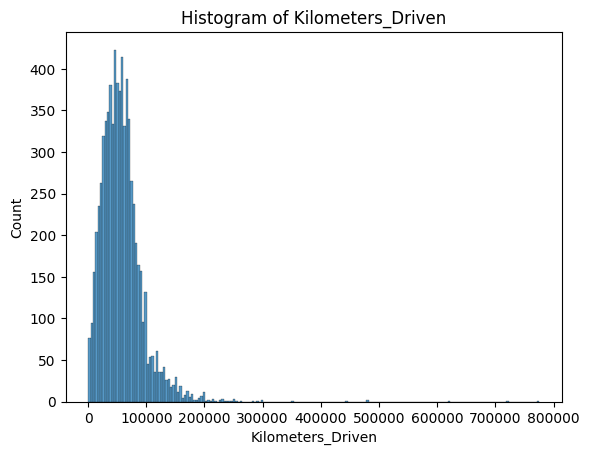

In [ ]:
# Histogram for 'Kilometers_Driven'
sns.histplot(df['Kilometers_Driven'])
plt.title('Histogram of Kilometers_Driven')
plt.xlabel('Kilometers_Driven')
plt.ylabel('Count')
plt.show()

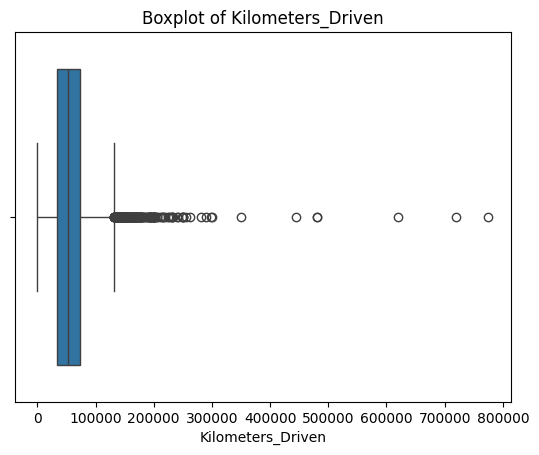

In [ ]:
# Boxplot for 'Kilometers_Driven'
sns.boxplot(x=df['Kilometers_Driven'])
plt.title('Boxplot of Kilometers_Driven')
plt.xlabel('Kilometers_Driven')
plt.show()

As shown, the histogram and boxplot are heavily skewed to the right with very few high values. A log transformation should be applied to this column to  better suit linear regression modeling later.

In [ ]:
# Log transformed dataset for 'Kilometers_Driven'
df['Kilometers_Driven_log'] = np.log(df['Kilometers_Driven'])

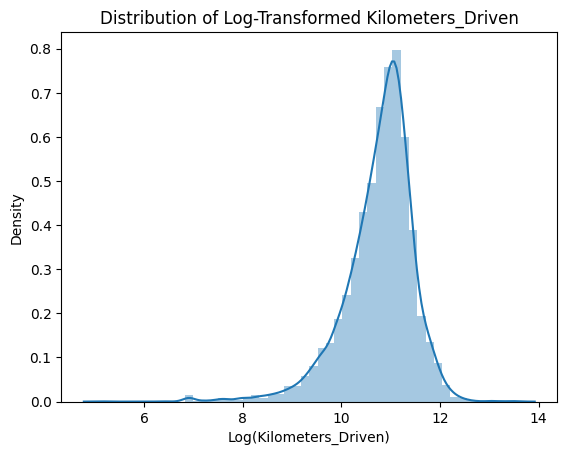

In [ ]:
# Distribution plot for log transformed 'Kilometers_Driven'
sns.distplot(df['Kilometers_Driven_log'], axlabel="Log(Kilometers_Driven)")
plt.title('Distribution of Log-Transformed Kilometers_Driven')
plt.show()

Added a log dataset for this specific column. After log transformation for 'Kilometers_Driven' column, a better suited distribution plot is shown.

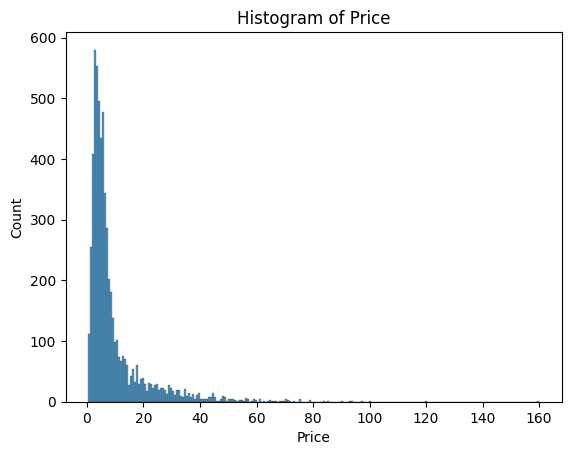

In [ ]:
# Histogram for 'Price'
sns.histplot(df['Price'])
plt.title('Histogram of Price')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

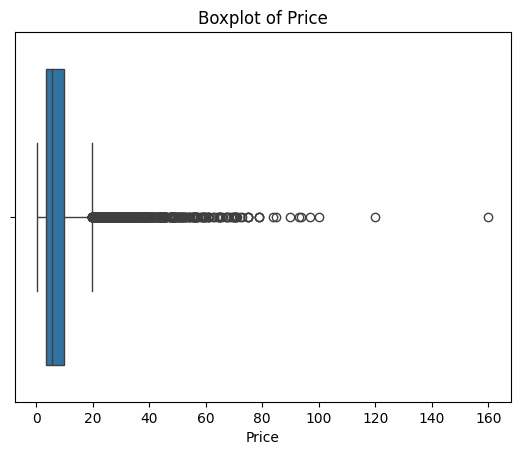

In [ ]:
# Boxplot for 'Price'
sns.boxplot(x=df['Price'])
plt.title('Boxplot of Price')
plt.xlabel('Price')
plt.show()

The histogram and boxplot for column 'Price' are also heavily skewed to the right, having very few high values. Again, a log transformation for this column should be applied for better suit of linear regression modeling.

In [ ]:
# Log transformed dataset for 'Price'
df['Price_log'] = np.log1p(df['Price'])

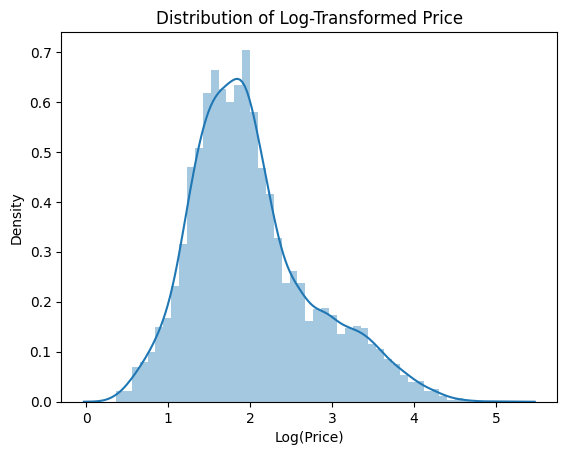

In [ ]:
# Distribution plot for log transformed 'Price'
sns.distplot(df['Price_log'], axlabel="Log(Price)")
plt.title('Distribution of Log-Transformed Price')
plt.show()

Added a log dataset for this specific column. After log transformation for 'Price' column, a better suited distribution plot is shown.

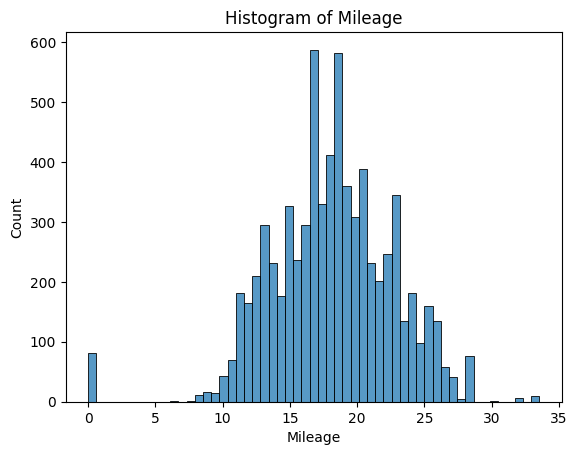

In [ ]:
# Histgram for 'Mileage'
sns.histplot(df['Mileage'])
plt.title('Histogram of Mileage')
plt.xlabel('Mileage')
plt.ylabel('Count')
plt.show()

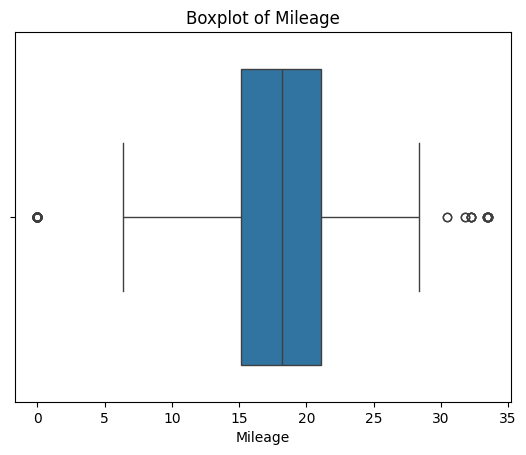

In [ ]:
# Boxplot for 'Mileage'
sns.boxplot(x=df['Mileage'])
plt.title('Boxplot of Mileage')
plt.xlabel('Mileage')
plt.show()

Histogram and boxplot for 'Mileage' seem well distributed, and doesn't seem necessary to do a log transformation.

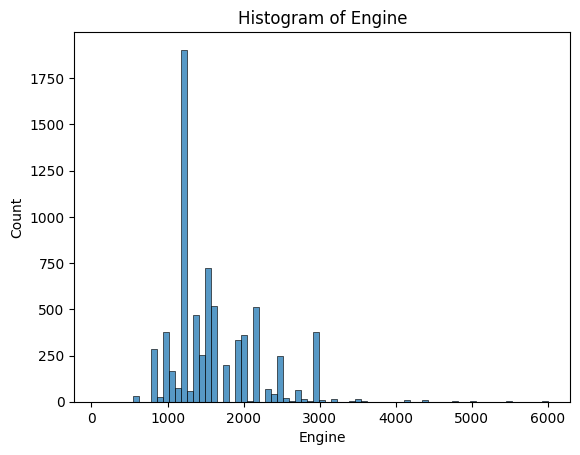

In [ ]:
# Histogram for 'Engine'
sns.histplot(df['Engine'])
plt.title('Histogram of Engine')
plt.xlabel('Engine')
plt.ylabel('Count')
plt.show()

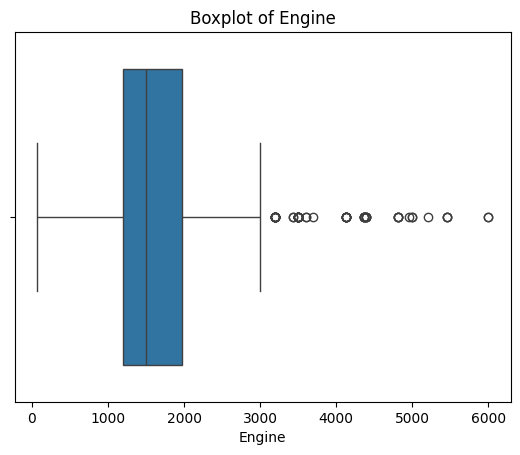

In [ ]:
# Boxplot for 'Engine'
sns.boxplot(x=df['Engine'])
plt.title('Boxplot of Engine')
plt.xlabel('Engine')
plt.show()

The 'Engine' column seems to have a noticable amount of outliers and skewness to the right. A log transformation might be necessary.

In [ ]:
# Log transformed dataset for 'Engine'
df['Engine_log'] = np.log1p(df['Engine'])

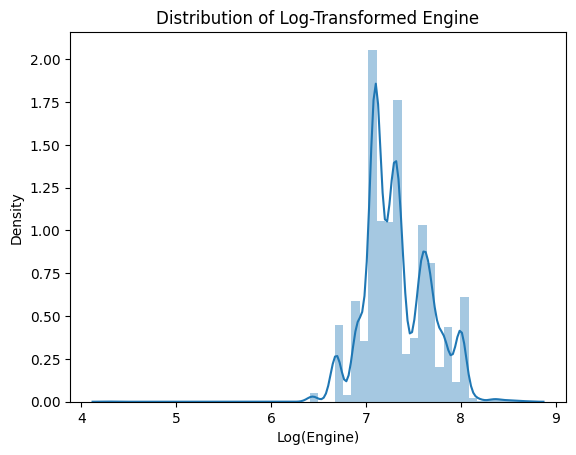

In [ ]:
# Distribution plot for log transformed 'Engine'
sns.distplot(df['Engine_log'], axlabel="Log(Engine)")
plt.title('Distribution of Log-Transformed Engine')
plt.show()

The log transformed plot does present a more normal distribution than before, but not enough in comparison with the other log transformed plots. Will check for distribution of reesiduals later on for analysis.

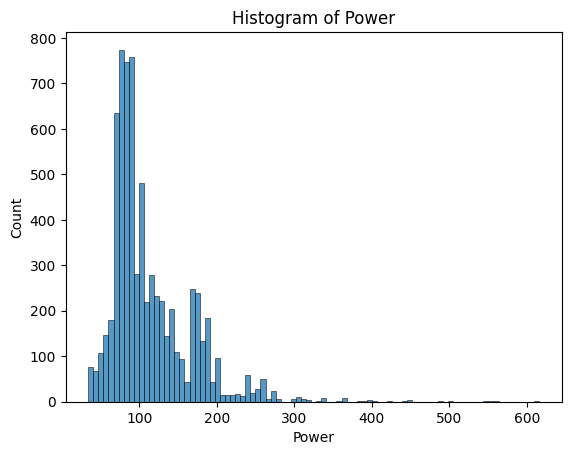

In [ ]:
# Histogram for Power
sns.histplot(df['Power'])
plt.title('Histogram of Power')
plt.xlabel('Power')
plt.ylabel('Count')
plt.show()

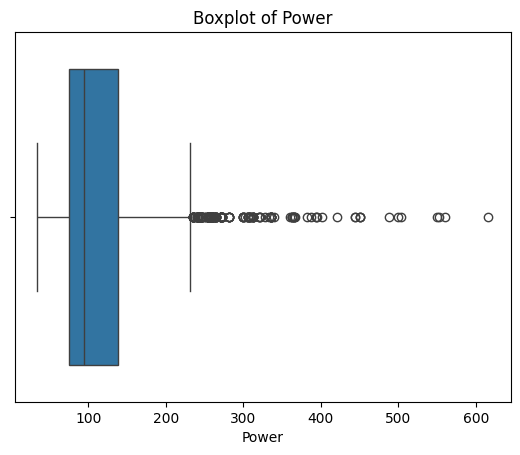

In [ ]:
# Boxplot for 'Power'
sns.boxplot(x=df['Power'])
plt.title('Boxplot of Power')
plt.xlabel('Power')
plt.show()

Histogram and boxplot shows high skewness and number of outliers. Needs a log transformation.

In [ ]:
# Log transformed dataset for 'Power'
df['Power_log'] = np.log1p(df['Power'])

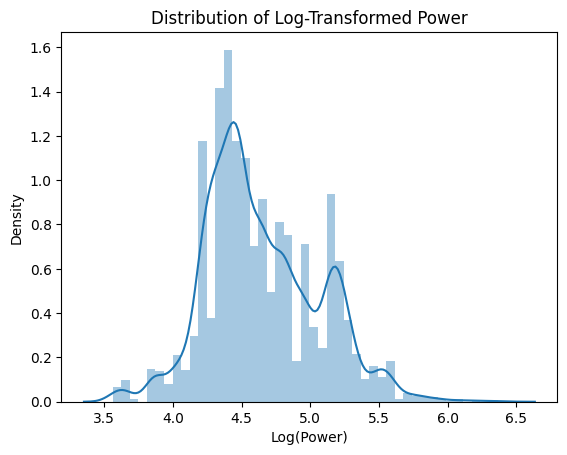

In [ ]:
# Distribution plot for log transformed 'Power'
sns.distplot(df['Power_log'], axlabel="Log(Power)")
plt.title('Distribution of Log-Transformed Power')
plt.show()

Although not perfect, the log transformed plot shows a better normal distribution than before.

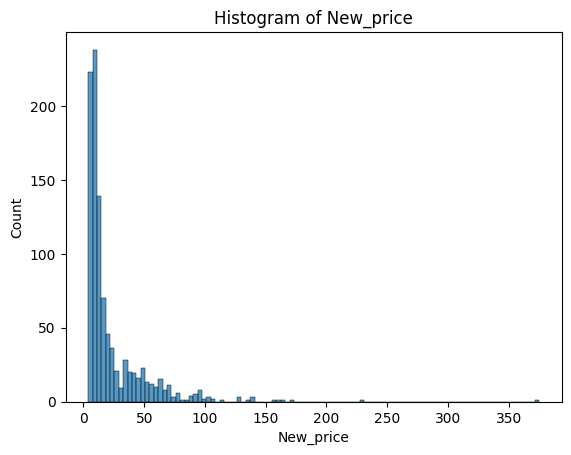

In [ ]:
# Histogram for 'New_price'
sns.histplot(df['New_price'])
plt.title('Histogram of New_price')
plt.xlabel('New_price')
plt.ylabel('Count')
plt.show()

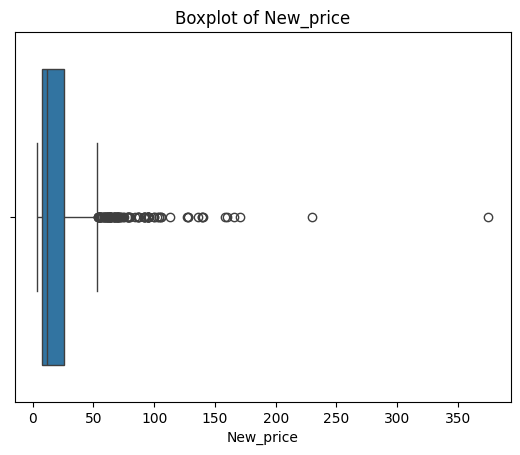

In [ ]:
# Boxplot for 'New_price'
sns.boxplot(x=df['New_price'])
plt.title('Boxplot of New_price')
plt.xlabel('New_price')
plt.show()

Histogram and boxplot show very high skewness and number of outliers. Crucially needs a log transformation.

In [ ]:
# Log transformed dataset for 'New_price'
df['New_price_log'] = np.log1p(df['New_price'])

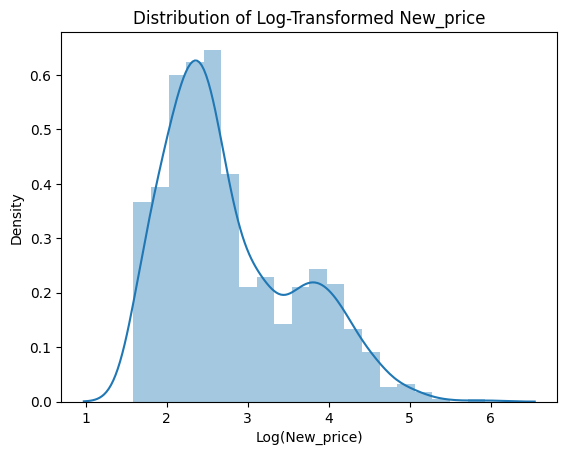

In [ ]:
# Distribution plot for log transformed 'New_price'
sns.distplot(df['New_price_log'], axlabel="Log(New_price)")
plt.title('Distribution of Log-Transformed New_price')
plt.show()

Although there is still some skewness, the log transformed plot shows a better normal distribution than before.

For 'Year' and 'Seats', while these are numerical variables, these columns are discrete counts that have very small ranges. Log transformations for these two will not be necessary, and instead, will be better presented in countplots for reference.

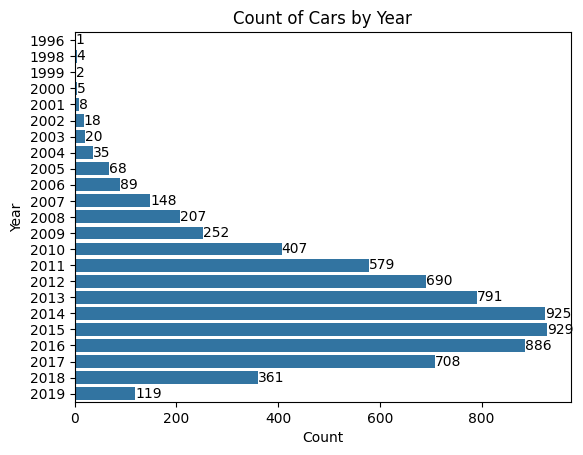

In [ ]:
# Countplot for 'Year'
ax = sns.countplot(data=df, y='Year')
plt.title('Count of Cars by Year')
plt.xlabel('Count')
plt.ylabel('Year')

# Add counts to the bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

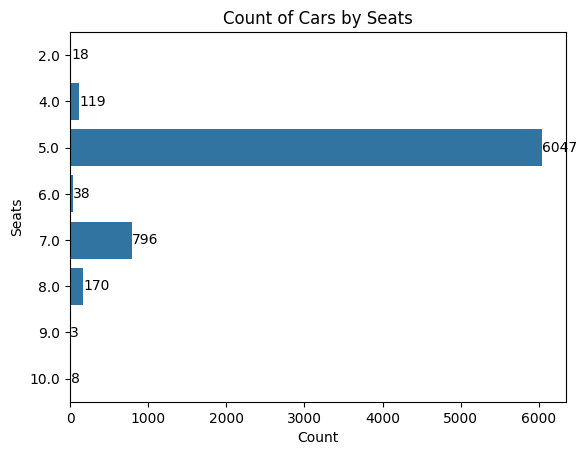

In [ ]:
# Countplot for 'Seats'
ax = sns.countplot(data=df, y='Seats')
plt.title('Count of Cars by Seats')
plt.xlabel('Count')
plt.ylabel('Seats')

# Add counts to the bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

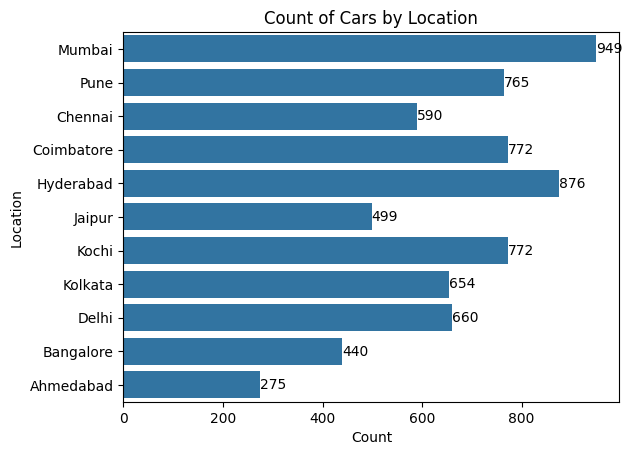

In [ ]:
# Countplot for 'Location'
ax = sns.countplot(data=df, y='Location')
plt.title('Count of Cars by Location')
plt.xlabel('Count')
plt.ylabel('Location')

# Add counts to the bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

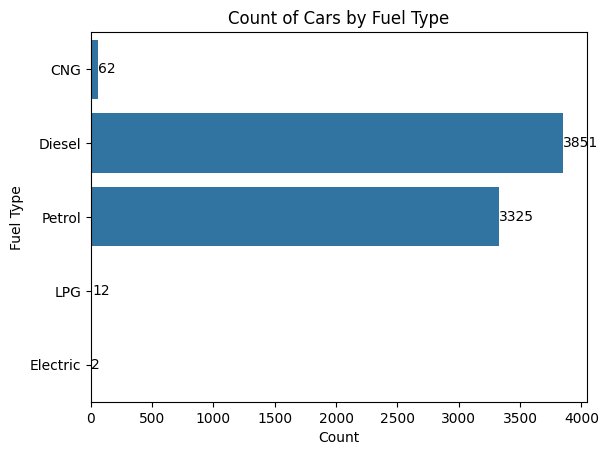

In [ ]:
# Countplot for 'Fuel_Type'
ax = sns.countplot(data=df, y='Fuel_Type')
plt.title('Count of Cars by Fuel Type')
plt.xlabel('Count')
plt.ylabel('Fuel Type')

# Add counts to the bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

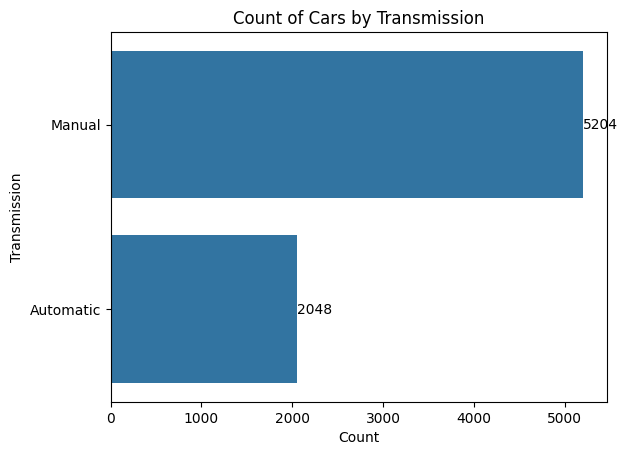

In [ ]:
# Countplot for 'Transmission'
ax = sns.countplot(data=df, y='Transmission')
plt.title('Count of Cars by Transmission')
plt.xlabel('Count')
plt.ylabel('Transmission')

# Add counts to the bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

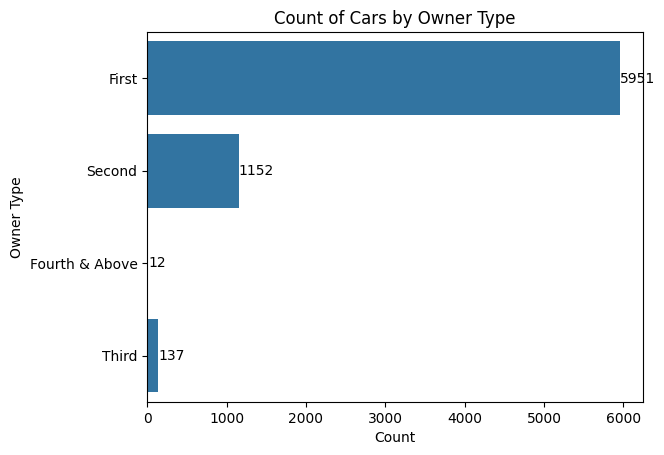

In [ ]:
# Countplot for 'Owner_Type'
ax = sns.countplot(data=df, y='Owner_Type')
plt.title('Count of Cars by Owner Type')
plt.xlabel('Count')
plt.ylabel('Owner Type')

# Add counts to the bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

Other cateogrical variables are also better represented as countplots for reference and don't require log transformations.

## **Bivariate Analysis**

**Questions:**

1. Plot a scatter plot for the log transformed values(if log_transformation done in previous steps)?
2. What can we infer form the correlation heatmap? Is there correlation between the dependent and independent variables?
3. Plot a box plot for target variable and categorical variable 'Location' and write your observations?

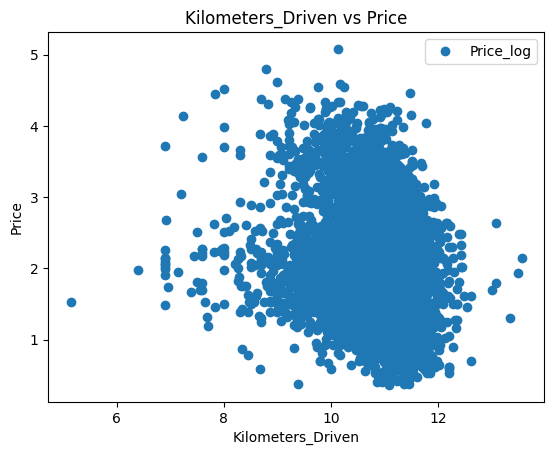

In [ ]:
# Scatterplot for log transformed 'Kilometers_Driven' vs 'Price'
df.plot(x='Kilometers_Driven_log', y='Price_log', style='o')
plt.title('Kilometers_Driven vs Price')
plt.xlabel('Kilometers_Driven')
plt.ylabel('Price')
plt.show()

The scatterplot shows an inverse relationship as with more kilometers driven, the lower the price gets. While this trend here is to be expected, the spread of points indicate that there are other influential factors that contribute to the price.

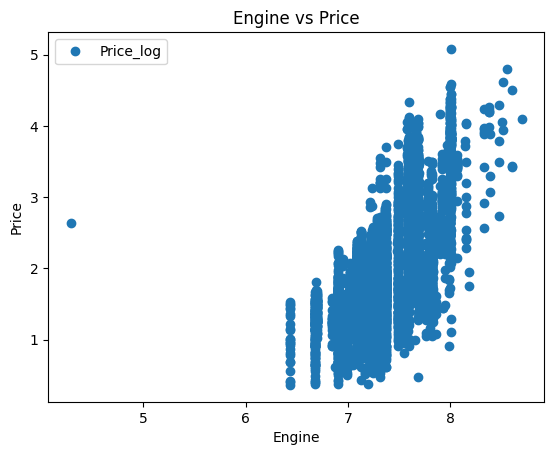

In [ ]:
# Scatterplot for log transformed 'Engine' vs 'Price
df.plot(x='Engine_log', y='Price_log', style='o')
plt.title('Engine vs Price')
plt.xlabel('Engine')
plt.ylabel('Price')
plt.show()

The general trend for the plot shows a postive relationship in which as the engine volume increases, the car price increases as well. There is one outlier point that could be caused by a data entry error, or another specific error. Again, the spread of the points indicate that there are other influential factors that contribute to the price.

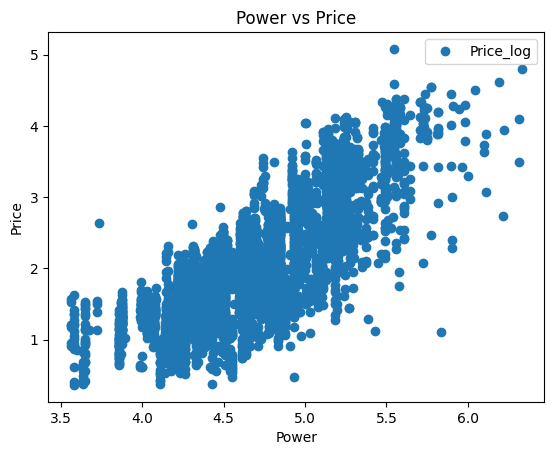

In [ ]:
# Scatterplot for log transformed 'Power' vs 'Price'
df.plot(x='Power_log', y='Price_log', style='o')
plt.title('Power vs Price')
plt.xlabel('Power')
plt.ylabel('Price')
plt.show()

The general trend for the plot shows a positive relationship in which as the engine power increases, so does the car price. There are some distinct points, but not enough to be considered outliers. Again, the spread of the points indiate that there are other influential factors that contribute towards the price.

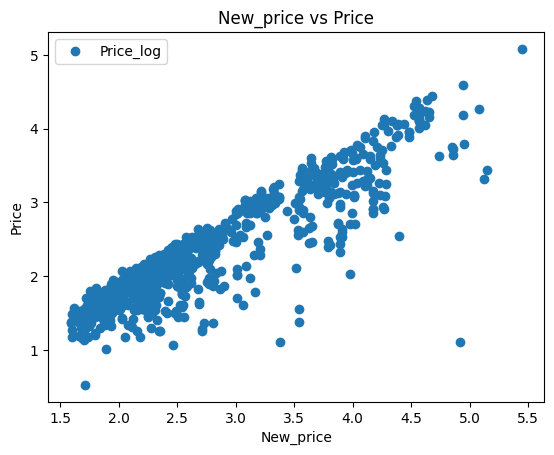

In [ ]:
# Scatterplot for log transformed 'New_price' vs 'Price'
df.plot(x='New_price_log', y='Price_log', style='o')
plt.title('New_price vs Price')
plt.xlabel('New_price')
plt.ylabel('Price')
plt.show()

The plot shows a more clear and linear relationship between each other, with mcuh less spread of points. This indicates that the 'New_price' variable is a highly signifiant factor of predicting the price for used cars.

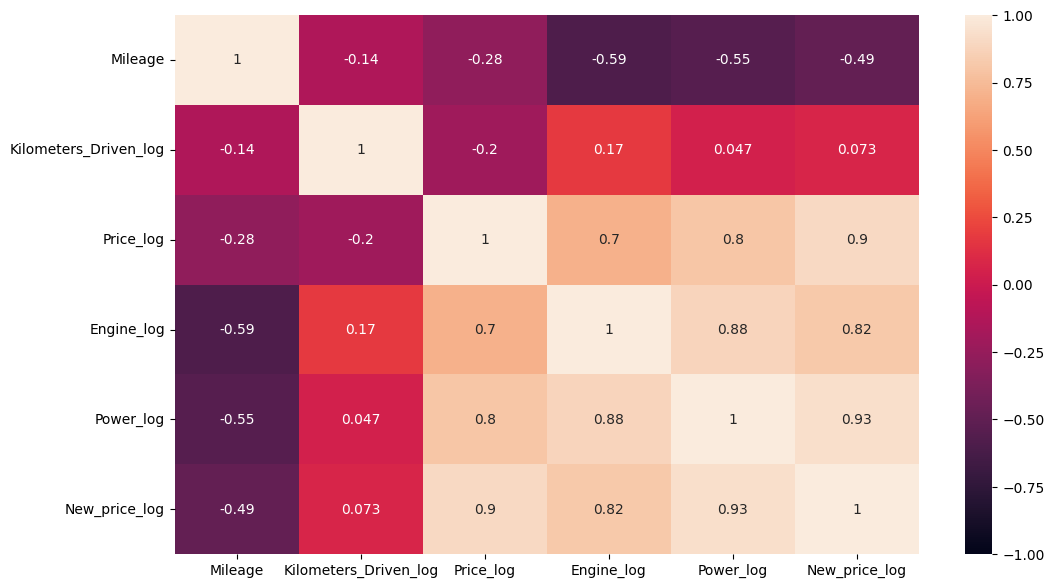

In [ ]:
# Heatmap of numerical variables
plt.figure(figsize = (12, 7))

sns.heatmap(df.drop(['Year','Seats','Kilometers_Driven','Engine','Power','New_price','Price'],axis = 1).corr(numeric_only = True), annot = True, vmin = -1, vmax = 1)

plt.show()

Dropping the 'Year', 'Seats', and all the remaining non-logged columns for the heatmap shows the correaltion of the six remaining numerical variables. The log transformed 'Engine', 'Power', and 'New_price' are the independent variables that have strong correlations with the dependent varaible 'Price' and with each other. These positive correlation values suggest that, as one goes up, the other also increases.

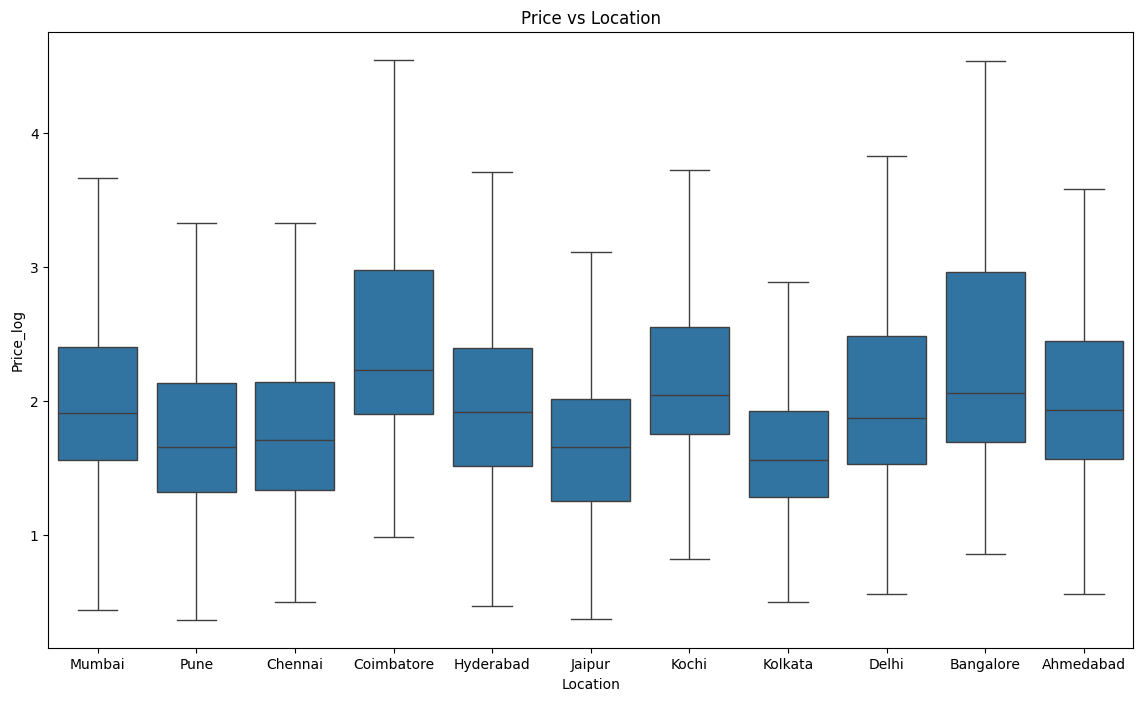

In [ ]:
# Boxplot of 'Location' vs 'Price' without the outliers
plt.figure(figsize=(14, 8))
sns.boxplot(x='Location', y='Price_log', data=df, showfliers=False)
plt.title('Price vs Location')
plt.xlabel('Location')
plt.show()

The variation of price distribution, and the differences of median price along with price spread, shows that location does play a factor in determining the price of used cars. A notable point from this is that the locations 'Jaipur' and 'Kolkata' have the shortest range and thus, the prices are less flexible in these two regions.

### **Feature Engineering**

**Think about it:** The `Name` column in the current format might not be very useful in our analysis.
Since the name contains both the brand name and the model name of the vehicle, the column would have too many unique values to be useful in prediction. Can we extract that information from that column?

* **Hint:** With 2041 unique names, car names are not going to be great predictors of the price in our current data. But we can process this column to extract important information for example brand name.

In [ ]:
df['Name'].str.split().str.get(0)

,Name
0,Maruti
1,Hyundai
2,Honda
3,Maruti
4,Audi
...,...
7248,Volkswagen
7249,Volkswagen
7250,Nissan
7251,Volkswagen


In [ ]:
# Extract Brand Names
df['Brand'] = df['Name'].str.split().str.get(0)

In [ ]:
# Extract Model Names
df['Model'] = df['Name'].str.split().str.get(1)

In [ ]:
# Check if Brand and Model have been extracted successfully
display(df[['Name', 'Brand', 'Model']].head(10))

,Name,Brand,Model
0,Maruti Wagon R LXI CNG,Maruti,Wagon
1,Hyundai Creta 1.6 CRDi SX Option,Hyundai,Creta
2,Honda Jazz V,Honda,Jazz
3,Maruti Ertiga VDI,Maruti,Ertiga
4,Audi A4 New 2.0 TDI Multitronic,Audi,A4
5,Hyundai EON LPG Era Plus Option,Hyundai,EON
6,Nissan Micra Diesel XV,Nissan,Micra
7,Toyota Innova Crysta 2.8 GX AT 8S,Toyota,Innova
8,Volkswagen Vento Diesel Comfortline,Volkswagen,Vento
9,Tata Indica Vista Quadrajet LS,Tata,Indica


The summary shows that the 'Brand' and 'Model' have been sucessfully extracted from the 'Name'

### **Missing value treatment**

In [ ]:
# Checking for missing values of each column
df.isnull().sum()

,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,46
Power,175


Moving on to the missing values, it seems like all the missing value counts are the same except one. Remember, we removed index 2328 that had the outlier for 'Kilometer_Driven' and that index had a missing 'New_price' value, so this would naturally decrease by 1. Otherwise, looks like there were no other values that were lost up to this process.

In [ ]:
# Impute missing values in 'Seats'
df['Seats']=df.groupby(['Brand','Model'])['Seats'].transform(lambda x: x.fillna(x.median()))

In [ ]:
# Check new missing values for 'Seats'
df['Seats'].isnull().sum()

np.int64(3)

After imputatation, the missing value count of 'Seats' decreased from 53 to 3, which is a significant improvement. The remaining 3 values is likely because those values belonged to a Brand and Model combination in which all entries were missing.

In [ ]:
# Impute missing values in 'Mileage'
df['Mileage'].fillna(df['Mileage'].median(), inplace=True)

In [ ]:
# Check new missing values for 'Mileage'
df['Mileage'].isnull().sum()

np.int64(0)

After imputation, the missing value count of 'Mileage' decreased from 2 to 0. As there were only 2 missing values to begin with, a more general method was used by imputing with the overall median on the entire dataset. This sucessfully filled in all missing values for this column.

In [ ]:
# Impute missing values in 'Engine_log'
df['Engine_log']=df.groupby(['Brand','Model'])['Engine_log'].transform(lambda x: x.fillna(x.median()))

In [ ]:
# Check new missing values for 'Engine_log'
df['Engine_log'].isnull().sum()

np.int64(0)

After imputation, the missing values of 'Engine_log' were all filled in.

In [ ]:
# Impute missing values in 'Power_log'
df['Power_log']=df.groupby(['Brand','Model'])['Power_log'].transform(lambda x: x.fillna(x.median()))

In [ ]:
# Check new missing values for 'Power_log'
df['Power_log'].isnull().sum()

np.int64(12)

After imputation, the missing value count for 'Power_log' decreased from 175 to 12. Similar to 'Seats', these 12 missing values belonged to the combination in which all entires were missing.

In [ ]:
# Impute missing values in 'New_price_log'
df['New_price_log'].fillna(df['New_price_log'].median(), inplace=True)

In [ ]:
df.dropna(subset=['Price_log'],inplace=True)

In [ ]:
# Check new missing values for 'New_price_log'
df['New_price_log'].isnull().sum()

np.int64(0)

After imputation through the fillna method, all the missing values from 'New_price_log' were filled in.

In [ ]:
# Check for the new number of missing values in the dataset
df=df.dropna(subset=['Seats','Power_log'])
print(df.isnull().sum())


Name                        0
Location                    0
Year                        0
Kilometers_Driven           0
Fuel_Type                   0
Transmission                0
Owner_Type                  0
Mileage                     0
Engine                     36
Power                     132
Seats                       0
New_price                5183
Price                       0
Kilometers_Driven_log       0
Price_log                   0
Engine_log                  0
Power_log                   0
New_price_log               0
Brand                       0
Model                       0
dtype: int64


For proper model building, it was crucial to drop the remaining missing values in 'Seats' and 'Power_log'. As we can see in the table, those two columns missing value count is now 0.

## **Important Insights from EDA and Data Preprocessing**

What are the the most important observations and insights from the data based on the EDA and Data Preprocessing performed?

## **Building Various Models**


1. What we want to predict is the "Price". We will use the normalized version 'price_log' for modeling.
2. Before we proceed to the model, we'll have to encode categorical features. We will drop categorical features like Name.
3. We'll split the data into train and test, to be able to evaluate the model that we build on the train data.
4. Build Regression models using train data.
5. Evaluate the model performance.

### **Split the Data**

<li>Step1: Seperating the indepdent variables (X) and the dependent variable (y).
<li>Step2: Encode the categorical variables in X using pd.dummies.
<li>Step3: Split the data into train and test using train_test_split.

**Question:**

1. Why we should drop 'Name','Price','price_log','Kilometers_Driven' from X before splitting?

In [ ]:
# Drop invalid columns and those that still have missing variables
X=df.drop(['Name','Price','Price_log','Kilometers_Driven','New_price','Engine','Power'],axis=1)
y=df[['Price_log','Price']]

As seen in the missing value count table, 'Engine', 'Power', and 'New_price' still had remaining missing values. Even though the log transformed data for those columns have been filled or removed, the orginal column data will get in the way of model building, so they were removed. Also, since the 'Price' and 'Price_log' are the dependent variable we are testing, those two were removed as well and instead put into Y.

In [ ]:
X=pd.get_dummies(X,drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
print(X_train.shape,X_test.shape)

(4204, 258) (1803, 258)


In [ ]:
print(X_train.isnull().sum().sum())

0


In [ ]:
print(y_train.isnull().sum().sum())

0


Before moving further, the missing value count for the training data was checked and successfully came out as 0. The training data features 4204 rows and 258 columns, while test data features 1803 rows and 258 columns.

For Regression Problems, some of the algorithms used are :<br>

**1) Linear Regression** <br>
**2) Ridge / Lasso Regression** <br>
**3) Decision Trees** <br>
**4) Random Forest** <br>

In [ ]:
def get_model_score(model, flag = True):
    '''
    model : regressor to predict values of X

    '''
    # Defining an empty list to store train and test results
    score_list = []

    pred_train = model.predict(X_train)

    pred_train_ = np.exp(pred_train)

    pred_test = model.predict(X_test)

    pred_test_ = np.exp(pred_test)

    train_r2 = metrics.r2_score(y_train['Price'], pred_train_)

    test_r2 = metrics.r2_score(y_test['Price'], pred_test_)

    train_rmse = np.sqrt(metrics.mean_squared_error(y_train['Price'], pred_train_))
    test_rmse = np.sqrt(metrics.mean_squared_error(y_test['Price'], pred_test_))

    # Adding all scores in the list
    score_list.extend((train_r2, test_r2, train_rmse, test_rmse))

    # If the flag is set to True then only the following print statements will be dispayed, the default value is True
    if flag == True:

        print("R-sqaure on training set : ", metrics.r2_score(y_train['Price'], pred_train_))

        print("R-square on test set : ", metrics.r2_score(y_test['Price'], pred_test_))

        print("RMSE on training set : ", np.sqrt(metrics.mean_squared_error(y_train['Price'], pred_train_)))

        print("RMSE on test set : ", np.sqrt(metrics.mean_squared_error(y_test['Price'], pred_test_)))

    # Returning the list with train and test scores
    return score_list

In [ ]:
# Input linear regression and fit it
lr=LinearRegression()
lr.fit(X_train,y_train['Price_log'])

# Get the model score
lr.score=get_model_score(lr)

R-sqaure on training set :  0.9309363439166032
R-square on test set :  0.8797691175907192
RMSE on training set :  2.9649777349262556
RMSE on test set :  3.763471980691889


- R-Square value of 0.93 on the training set indicates that the model can explain around 93.1% of the variation of the log-transformed car prices from the used data. Also, as the number is close to 1, it indicates a good fit.
- R-Square value of 0.88 on the test set indicates that the model can explain around 88% of variation for log-transformed car prices for new unseen data. Although the number is slightly lower than the train value which indicates slight overfitting, it still captures the main patterns in the data
- RMSE values for both the train and test data are relatively high, indicating that the model's predictions are likely to have errors.
- Overall, while this model can capture the overall trends, it will still have problems predicting an accurate price for unknown individual car prices.

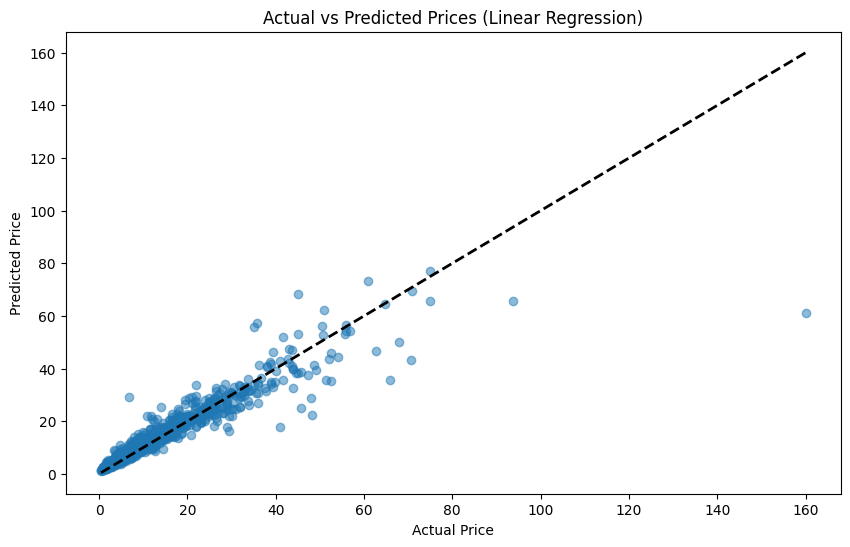

In [ ]:
# Plotting actual vs predicted prices for Linear Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test['Price'], np.exp(lr.predict(X_test)), alpha=0.5)
plt.plot([y_test['Price'].min(), y_test['Price'].max()], [y_test['Price'].min(), y_test['Price'].max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (Linear Regression)')
plt.show()

Linear regression plot seems well made as most of the points lean towards to the regression line with minimal outliers.



In [ ]:
# Input ridge regression and fit it with random state=1
ridge=Ridge(random_state=1)
ridge.fit(X_train,y_train['Price_log'])

# Get the model score
ridge.score=get_model_score(ridge)

R-sqaure on training set :  0.9231943091816501
R-square on test set :  0.8905215120379828
RMSE on training set :  3.126751405027882
RMSE on test set :  3.5912452541031366


- R-square value of 0.92, which is close to 1, indicates that the training set fit well
- R-square value of 0.89 for the test set shows a good generalization for unseen data
- Difference between the train and test set values indicate slight overfitting
- The high RMSE numbers indicate that there will be some errors in predicting unknown car prices

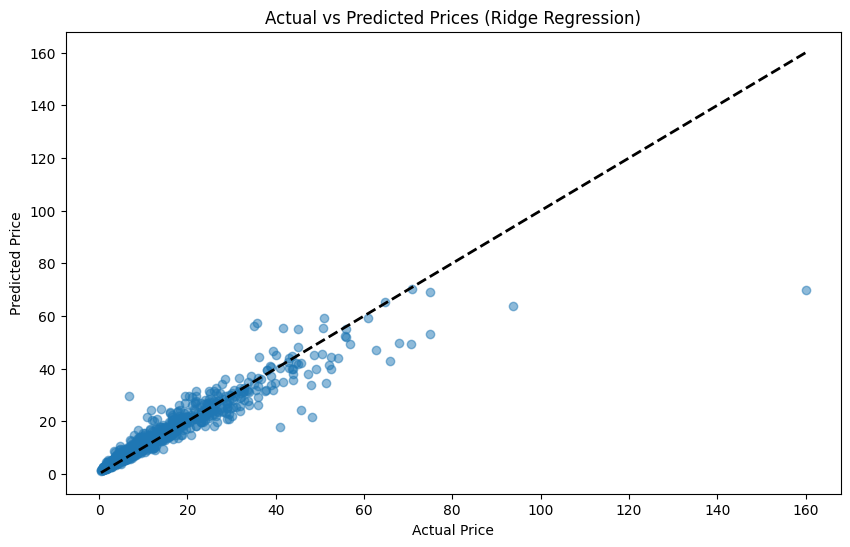

In [ ]:
# Plotting actual vs predicted prices for Ridge Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test['Price'], np.exp(ridge.predict(X_test)), alpha=0.5)
plt.plot([y_test['Price'].min(), y_test['Price'].max()], [y_test['Price'].min(), y_test['Price'].max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (Ridge Regression)')
plt.show()

Ridge model plot seems well made as most of the points lean toward to the regression line with minimal outliers.

In [ ]:
# Input lasso regression and fit it with random state=1
lasso=Lasso(random_state=1)
lasso.fit(X_train,y_train['Price_log'])

# Get the model score
lasso.score=get_model_score(lasso)

R-sqaure on training set :  -0.0023683186895595565
R-square on test set :  0.0032645304139652387
RMSE on training set :  11.295626397336445
RMSE on test set :  10.836040670384415


- R-squared values for both the train and test set indicate this model is an extremely poor fit and explains none of the variance in the target variable
- These value shows that this lasso model has no prediction capability which also explains the very high RMSE values which indicates huge errors

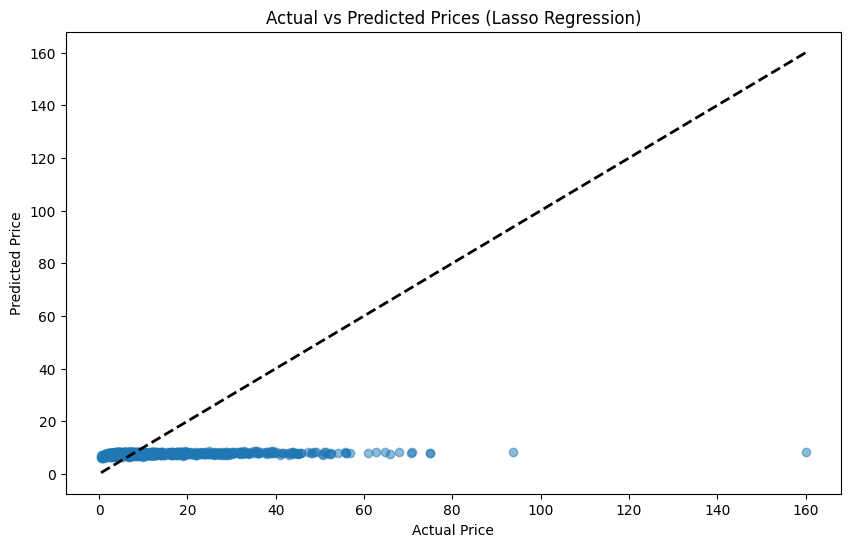

In [ ]:
# Plotting actual vs predicted prices for Lasso Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test['Price'], np.exp(lasso.predict(X_test)), alpha=0.5)
plt.plot([y_test['Price'].min(), y_test['Price'].max()], [y_test['Price'].min(), y_test['Price'].max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (Lasso Regression)')
plt.show()

Lasso regression plot came out bad, as almost all the points are just a flat line not even coming close to the regression line.

### **Hyperparameter Tuning: Decision Tree**

In [ ]:
# Input decision tree regression and fit it with random state=1
dtree=DecisionTreeRegressor(random_state=1)
dtree.fit(X_train,y_train['Price_log'])

# Get the model score
dtree.score=get_model_score(dtree)

R-sqaure on training set :  0.9921409493053757
R-square on test set :  0.8153540590040091
RMSE on training set :  1.0001881363874845
RMSE on test set :  4.663914200468404


- R-square value of 0.99 and RMSE value of 1, indicates that the training data fits almost perfectly and learned the trends/noise very closely
- The big difference of the train and test values for the r-square and RMSE indicates that this model is overfitting the training data, and will not generalize well to unseen data
- The significantly high RMSE value for the test set also indicates that there will be a high rate of error for predicting unknown car prices

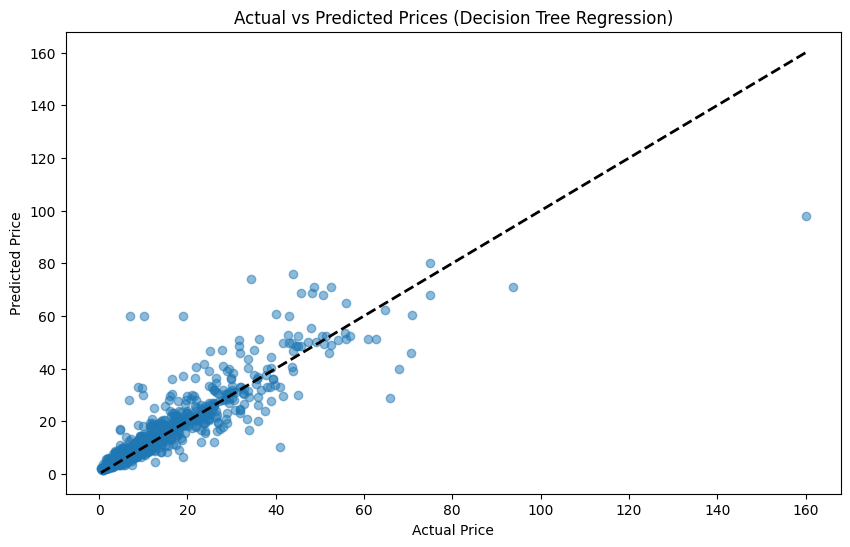

In [ ]:
# Plotting actual vs predicted prices for Decision Tree Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test['Price'], np.exp(dtree.predict(X_test)), alpha=0.5)
plt.plot([y_test['Price'].min(), y_test['Price'].max()], [y_test['Price'].min(), y_test['Price'].max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (Decision Tree Regression)')
plt.show()

For the decision tree, there is a bit more spread of data points than the other models, but still came out decently.

**Feature Importance**

In [ ]:
# Check feature importances from the Decision Tree model

print(pd.DataFrame(dtree.feature_importances_, columns=["Imp"], index=X_train.columns).sort_values(by='Imp', ascending=False))

                            Imp
Power_log              0.652769
Year                   0.203534
Engine_log             0.019755
Kilometers_Driven_log  0.016881
Brand_Mercedes-Benz    0.012494
...                         ...
Model_Verito           0.000000
Model_WR-V             0.000000
Model_Versa            0.000000
Model_X-Trail          0.000000
Model_WRV              0.000000

[258 rows x 1 columns]


<Figure size 1000x600 with 0 Axes>

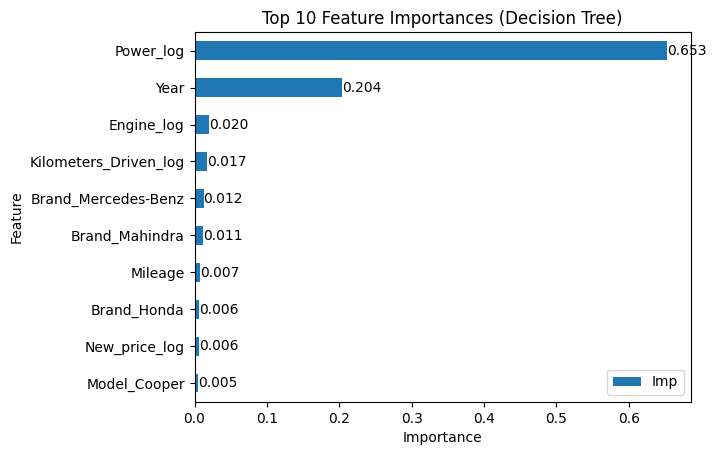

In [ ]:
# Plot the top 10 feature importances
sorted_feature_importance_dt = pd.DataFrame(dtree.feature_importances_, columns=["Imp"], index=X_train.columns).sort_values(by='Imp', ascending=False)

plt.figure(figsize=(10, 6))
ax = sorted_feature_importance_dt.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f') # Format to 3 decimal places

plt.show()

We can see that the 'Power_log' and 'Year' variables were the most important and influential in this building the decision tree model.

### **Hyperparameter Tuning: Random Forest**

In [ ]:
# Input random forest regression and fit it with random state=1
rf=RandomForestRegressor(random_state=1)
rf.fit(X_train,y_train['Price_log'])

# Get the model score
rf.score=get_model_score(rf)

R-sqaure on training set :  0.9746251470201629
R-square on test set :  0.8697574571424533
RMSE on training set :  1.7972083228720852
RMSE on test set :  3.917031852572171


- R-square value of 0.97 indicates that the model fits the training data really well
- The difference between the values from the train and test sets still indicate overfitting
- High RMSE values indicate that this model will have some errors in prediction

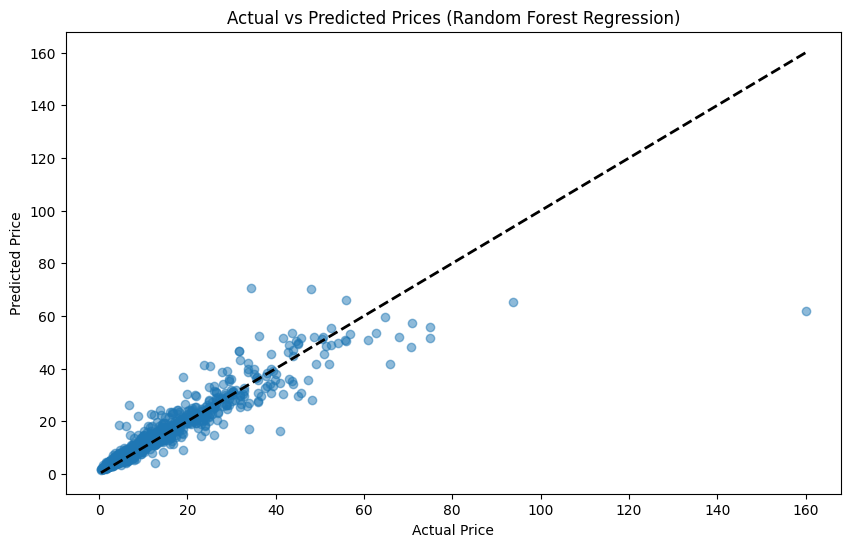

In [ ]:
# Plotting actual vs predicted prices for Random Forest Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test['Price'], np.exp(rf.predict(X_test)), alpha=0.5)
plt.plot([y_test['Price'].min(), y_test['Price'].max()], [y_test['Price'].min(), y_test['Price'].max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices (Random Forest Regression)')
plt.show()

Random forest plot seems well made as most of the points lean toward to the regression line with minimal outliers.

**Feature Importance**

In [ ]:
# Check feature importances from the Decision Tree model

print(pd.DataFrame(rf.feature_importances_, columns=["Imp"], index=X_train.columns).sort_values(by='Imp', ascending=False))

                            Imp
Power_log              0.662191
Year                   0.204943
Engine_log             0.025020
Kilometers_Driven_log  0.016695
Mileage                0.010344
...                         ...
Model_Evalia           0.000000
Model_Prius            0.000000
Model_MUX              0.000000
Model_SL-Class         0.000000
Model_WR-V             0.000000

[258 rows x 1 columns]


<Figure size 1000x600 with 0 Axes>

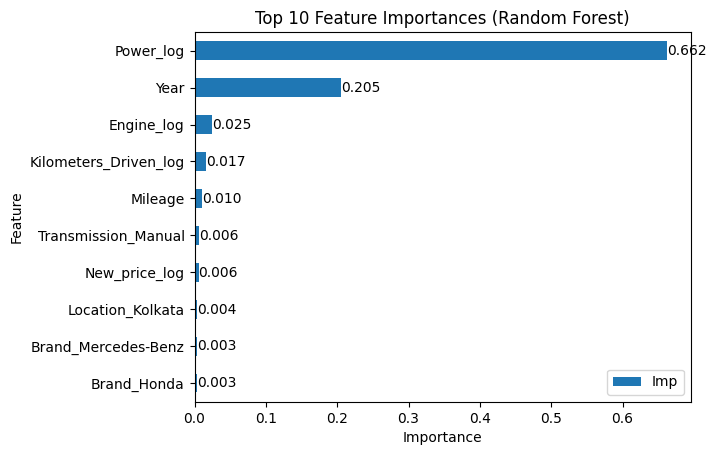

In [ ]:
# Plot the top 10 feature importances
sorted_feature_importance_dt = pd.DataFrame(rf.feature_importances_, columns=["Imp"], index=X_train.columns).sort_values(by='Imp', ascending=False)

plt.figure(figsize=(10, 6))
ax = sorted_feature_importance_dt.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f') # Format to 3 decimal places

plt.show()

Same as the Decision Tree, the 'Power_log' and 'Year' were the most important and influential variables in building the random forest model.

## **Conclusions and Recommendations**

**1. Comparison of various techniques and their relative performance based on chosen Metric (Measure of success):**
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

In [ ]:
models=[lr, ridge, lasso, dtree, rf]
r2_train=[]
r2_test=[]
rmse_train=[]
rmse_test=[]

for model in models:

  s = get_model_score(model, False)
  r2_train.append(s[0])
  r2_test.append(s[1])
  rmse_train.append(s[2])
  rmse_test.append(s[3])

scores_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Decision Tree', 'Random Forest'],
    'Train R2': r2_train,
    'Test R2': r2_test,
    'Train RMSE': rmse_train,
    'Test RMSE': rmse_test
})
display(scores_df)

,Model,Train R2,Test R2,Train RMSE,Test RMSE
0,Linear Regression,0.930936,0.879769,2.964978,3.763472
1,Ridge,0.923194,0.890522,3.126751,3.591245
2,Lasso,-0.002368,0.003265,11.295626,10.836041
3,Decision Tree,0.992141,0.815354,1.000188,4.663914
4,Random Forest,0.974625,0.869757,1.797208,3.917032


- Lasso regression performed the worst, as it's R-squared values are very close to 0 and the RMSE values are very high. This model is currently not suitable for price prediction. For this to be used, hyperparameter tuning of the regularization strength would be needed.
- Decision tree had the highest R-squared value of the training set, meaning that training data fit almost perfectly. However, the performance significantly dropped on the test set, indicating overfitting. The model learned the training data too well including its noise, and doesn't generalize well to unseen data. This model is not the best to use for price prediction.
- Linear and Random forest had a generally good performance, but the gap between the train and test values shows overfitting
- Ridge regression performed the best, as it had reasonable values with the smallest gap between the train and test set, so there was no overfitting issue. This model seems to be the best choice to use for car price prediction.



**2. Executive Summary:**

Based on the heatmap, the variables 'Engine', 'Power' and 'New price' had the highest correlation to the 'Price' dependent variable, meaning that these variables are the most significant in determining the used car prices. The strong postive correlation values show that as one of these variables goes up, the price increases as well. The 'Mileage' and 'Kilometers Driven' variables had the lowest correlation value towards 'Price', showing the least significance for price determination. However, it looks like the 'Year' and Kilometers Driven' variables were also took into consideration when building the Decision Tree and Random Forest models. Categories like Electric and LPG from 'Fuel type' and Fourth & Above for'Owner type', had too little entries, which made it hard to make relationships for those. Overall there were no particular variable that was considered invalid or useless, so all of them were used for building the model.

From the milestone, the dataset was processed again with a few edits and the models were built again, giving new model scores and implications. Based on the model score summary table, it is concluded that the Ridge regression model was best suited for use as a prdiction model for unknown used car prices. This model had a r-squared test score of 0.89 and a RMSE score of 3.59, which was the lowest of all the model RMSE scores.

**3. Problem and Solution Summary:**

The entire purpose of this project was to solve the problem of uncertainly in predicting reasonable prices for used cars. As there are many variables that influence a price of a car, we needed to find out in which way and how much each of these variables affect the used car price. For that, various prediction models were built, and we had to find out which model would be best suited for Cars4U to use.

Based on the model score results, it was concluded that the Ridge regression model would be the best model to use. Again, it had the highest R-squared value and the lowest RMSE value on the test set. The gap in values between the train and test set implicates that minimal issues for data fitting and a consistance compared to the training set. Ridge regression in general uses L2 regularization which helps shrink coefficients of the variables. As there are many variables to work it, this was helpful and also took into consideration of multicolinnearity. Overall, this model had effective regularization along with a good balance of performance and interpretability. As the best model to predict unknown used car prices, buisness can apply to this model to provide reasonable, data-driven price esitmates of their used cars, and help devise strategies to better compete with other car markets.

---



**4. Recommendations for Implementation**

- **Use model as a pricing tool system online**: A model such as this can be implemented on a website or system, so that both buyers and sellers can get a good grasp of the estimate/average price of a specific car. It should also have to option to play with the variables such as 'Year' or 'Kilometers Driven' so that buyers can explore their options based on their budget. Each buyer would have their own preferance of which variable would be imporant to them, so this system will be very helpful.
- **Monitor Model Performance**: While the model refers to various variables, there are still some that are missing that exists in real life. Some examples can be inflation, short supply, interest rate, exchange rates and more. Later on, when the economy takes a sudden change, it would be good to revise the model and update it as needed.
- **Use the model as a starting point**: The model isn't perfect and isn't an absolute guideline for determing prices. As there are car dealerships that tend to negotiate prices, some human research and reference will need to determine the price for each specific car.

**Recommendation for stakeholders**

- Keep using and analyzing the model as a pricing tool. This would be the most accessible for any buyer or seller to refer to, and so it is crucial to keep this up to date and fix and changes that are needed
- Compare the model's predicted prices with own knowledge and give even the smallest feedback
- Incorporate model findings into strategy that can help with marketing

**5. Risks and Limitations**

- This model is performing with an RMSE score of 3.59, which means there is a notable average prediction error. This is why this model should only be used as a starting point, and human knowledge is required. The predictions can be wrong when solely relying on the model.
- While most outliers were made less sensitive from regularization, extreme outliers still have the potential to influence model's prediction
- As a linear model, this ridge model only takes into consideration the effects of each variable independently. A combiniation of two or more variables that affects the car price negatively, can have a more significant effect on the price than individually combined.

**6. Final Conclusion and Improvements**

Overall, this Ridge model is the best bet for Cars4U to use, but still needs human interaction in determing car prices. The limitations and recommendations all circle back to how the model isn't perfect and can be improved. While the r-squared values of the test set can be improved, it is more crucial to somehow fix the RMSE value to reduce the prediction errors.

Some suggestions on that could possibly be

- Hyperparameter Tuning
- Collect more or better data
- Use more advanced modeling technique